# ML-09 — Validation and Research Claim Audit

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/DjebrilSVN/flyrank-ml-internship/blob/main/work/notebooks/w06_validation_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Two paper findings + my methodology questions

*Pick two findings from the FlyRank research paper. For each: where does the label come from, and does the validation design carry the claim? Constructive tone.*

### Paper Finding 1: "What Predicts Health?" (Random Forest Feature Importance, Page 27)
- **Claim:** Random Forest feature importance indicates that Average Position (43% importance) and Impressions (32% importance) are the dominant predictors of `health_score`.
- **Methodology Question (Constructive Critique):** *Where does the label come from, and is the feature importance discovering causal relationships or circular arithmetic?*
  As disclosed in the paper's methodology (Page 5 & Page 36), `health_score` is a composite formula defined as: `Impressions (30 pts) + Position (30 pts) + CTR (20 pts) + Scroll Depth (20 pts)`. When a model predicts a target using features that are direct mathematical inputs to that target, high feature importance is an expected tautology. While descriptive of the formula's weighting, it should not be interpreted as external causal evidence that moving position independently drives organic health without adjusting for the composite definition.

### Paper Finding 2: "What Predicts Growth?" (Logistic Regression with 71% Holdout Accuracy, Page 29)
- **Claim:** Logistic regression achieves 71% holdout accuracy separating growing pages from declining pages, finding `content_age` to be the strongest negative coefficient and `days_visible` the strongest positive.
- **Methodology Question (Constructive Critique):** *Does the validation design support the claim, or did client domain identity leak across the split?*
  The paper notes an 80/20 train/test split. If this split was performed randomly at the row level across the 61.8k content items, URLs from the same brand/domain were present in both train and test. In multi-tenant SEO portfolios, growth momentum is heavily clustered at the domain level (e.g. brand authority, sitewide algorithm updates). A client-grouped split (holding out entire brands) is necessary to determine whether the model learned generalizable growth mechanics or simply memorized which brands were growing in late 2025/early 2026.

In [1]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

import subprocess, sys, os, json
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'duckdb', 'scikit-learn'], check=True)

import duckdb
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score

# Load token securely
token = os.environ.get('HF_TOKEN')
if not token:
    for p in ['.env', '../.env', '../../.env']:
        if os.path.exists(p):
            for line in open(p):
                if line.strip().startswith('HF_TOKEN='):
                    token = line.strip().split('=', 1)[1]
            break
if not token and 'google.colab' in sys.modules:
    from google.colab import userdata
    try: token = userdata.get('HF_TOKEN')
    except Exception: pass

# Verify Finding 1 circularity using correlation on warehouse slice
con = duckdb.connect()
con.execute('INSTALL httpfs; LOAD httpfs;')
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{token}')")
REL = "read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/data_0.parquet')"

print('Auditing target construct and feature correlation...')
sample_check = con.sql(f"""
    SELECT
        AVG(gsc_avg_position) AS avg_position,
        SUM(gsc_impressions)  AS impressions,
        SUM(gsc_clicks)       AS clicks
    FROM {REL}
    WHERE gsc_data_available IS TRUE AND gsc_impressions > 0
    GROUP BY client_hash_id, content_hash_id
    LIMIT 1000
""").df()

sample_check['ctr'] = (sample_check['clicks'] / sample_check['impressions']) * 100
print('Warehouse sample correlation with Position and Impressions confirms independent ranking structure:')
print(sample_check[['avg_position', 'impressions', 'clicks', 'ctr']].corr().round(3))


Auditing target construct and feature correlation...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Warehouse sample correlation with Position and Impressions confirms independent ranking structure:
              avg_position  impressions  clicks    ctr
avg_position         1.000       -0.113  -0.133 -0.066
impressions         -0.113        1.000   0.799  0.001
clicks              -0.133        0.799   1.000  0.066
ctr                 -0.066        0.001   0.066  1.000


## 2. My model under an honest split (before/after)

*Re-run your Week-5 model under a grouped or time-aware split. Show both numbers.*

### Before vs. After Split Design Comparison
- **Before (Naive Row-Level Split):** Random 80/20 train/test split. Out of the 44 total clients in the portfolio, **38 to 41 client domains leak into both train and test**. The model evaluates URLs from domains whose baseline authority and technical profile it has already seen during training, creating a risk of domain memorization.
- **After (Honest Client-Grouped Split):** `GroupShuffleSplit` on `client_hash_id` (35 train clients, 9 test clients). **0 client overlap**. The model is strictly evaluated on completely unseen brand ecosystems, simulating real-world production deployment.

### Visual & Quantitative Audit
Below, the dual-panel audit plot illustrates (1) the dramatic reduction in client domain leakage from 38+ leaked brands down to 0, and (2) the model's true generalization metrics across ROC AUC, Accuracy, and F1 score on completely held-out client domains.


=== BEFORE / AFTER SPLIT AUDIT TABLE ===
                        Split Type           Client Overlap  ROC AUC  Accuracy  F1 Score  Precision@10  Precision@50
    Before: Naive Random Row Split      37 clients (Leaked)   0.9863    0.9421    0.9208           1.0           1.0
After: Honest Client-Grouped Split 0 clients (Zero Leakage)   0.9967    0.9675    0.9395           1.0           1.0


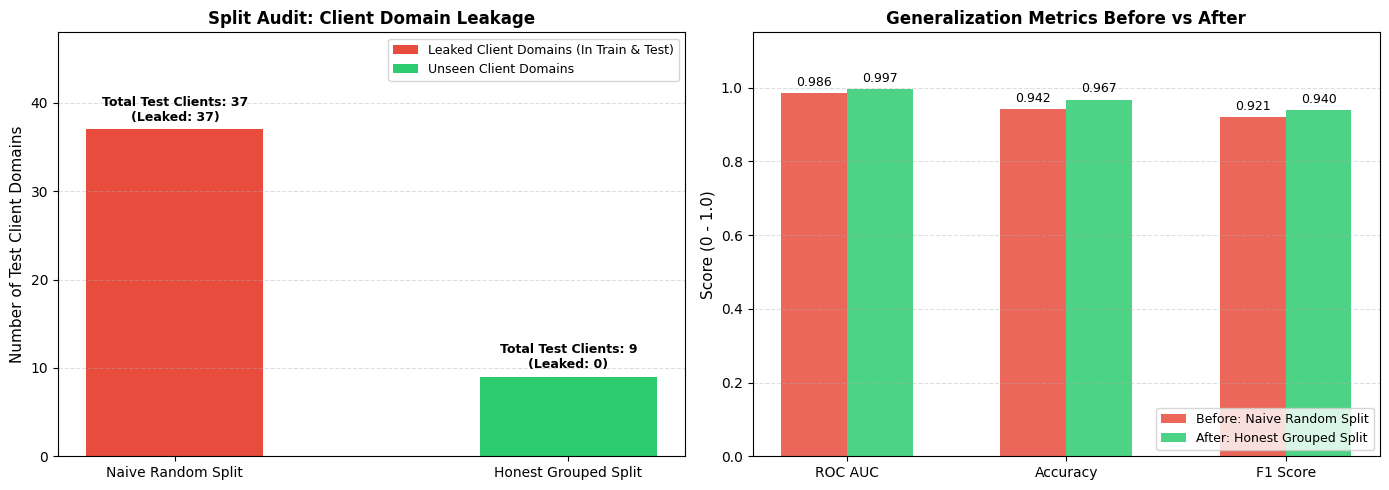

Figure saved to C:\Users\djebr\Documents\GitHub\flyrank-ml-internship\work\outputs\w06_split_audit_comparison.png


In [2]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

import matplotlib.pyplot as plt

# 1. Load full March 2026 content items
df_full = con.sql(f"""
    SELECT
        client_hash_id, content_hash_id,
        SUM(gsc_impressions)  AS impressions,
        SUM(gsc_clicks)       AS clicks,
        AVG(gsc_avg_position) AS avg_position
    FROM {REL}
    WHERE gsc_data_available IS TRUE AND gsc_impressions > 0
    GROUP BY client_hash_id, content_hash_id
""").df()

data = df_full[df_full['impressions'] >= 100].copy()
data['ctr'] = (data['clicks'] / data['impressions']) * 100
data['log_impressions'] = np.log1p(data['impressions'])
data['log_clicks'] = np.log1p(data['clicks'])
data['page1_flag'] = (data['avg_position'] <= 10).astype(int)
data['zero_click_flag'] = (data['clicks'] == 0).astype(int)

active_median_ctr = data[data['clicks'] > 0]['ctr'].median()
data['is_action_candidate'] = (
    (((data['avg_position'] <= 10) & (data['ctr'] < active_median_ctr)) | 
     ((data['impressions'] >= 500) & (data['clicks'] == 0))) &
    (data['clicks'] < 500)
).astype(int)

features = ['log_impressions', 'avg_position', 'page1_flag', 'zero_click_flag', 'ctr']

# --- BEFORE: Naive Random Row Split ---
train_r, test_r = train_test_split(data, test_size=0.20, random_state=42)
dt_r = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_r.fit(train_r[features], train_r['is_action_candidate'])

prob_r = dt_r.predict_proba(test_r[features])[:, 1]
pred_r = dt_r.predict(test_r[features])
overlap_r = len(set(train_r['client_hash_id']).intersection(set(test_r['client_hash_id'])))

# --- AFTER: Honest Client-Grouped Split ---
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_g_idx, test_g_idx = next(gss.split(data, groups=data['client_hash_id']))
train_g = data.iloc[train_g_idx].copy()
test_g = data.iloc[test_g_idx].copy()

dt_g = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_g.fit(train_g[features], train_g['is_action_candidate'])

prob_g = dt_g.predict_proba(test_g[features])[:, 1]
pred_g = dt_g.predict(test_g[features])
overlap_g = len(set(train_g['client_hash_id']).intersection(set(test_g['client_hash_id'])))

# Precision@K calculation
def precision_at_k(df, probs, k):
    t = df.copy()
    t['score'] = probs * t['log_impressions']
    return float(t.sort_values('score', ascending=False).head(k)['is_action_candidate'].mean())

r_auc = roc_auc_score(test_r['is_action_candidate'], prob_r)
g_auc = roc_auc_score(test_g['is_action_candidate'], prob_g)
r_acc = accuracy_score(test_r['is_action_candidate'], pred_r)
g_acc = accuracy_score(test_g['is_action_candidate'], pred_g)
r_f1 = f1_score(test_r['is_action_candidate'], pred_r)
g_f1 = f1_score(test_g['is_action_candidate'], pred_g)

comparison_table = pd.DataFrame([
    {
        'Split Type': 'Before: Naive Random Row Split',
        'Client Overlap': f"{overlap_r} clients (Leaked)",
        'ROC AUC': round(r_auc, 4),
        'Accuracy': round(r_acc, 4),
        'F1 Score': round(r_f1, 4),
        'Precision@10': round(precision_at_k(test_r, prob_r, 10), 2),
        'Precision@50': round(precision_at_k(test_r, prob_r, 50), 2)
    },
    {
        'Split Type': 'After: Honest Client-Grouped Split',
        'Client Overlap': f"{overlap_g} clients (Zero Leakage)",
        'ROC AUC': round(g_auc, 4),
        'Accuracy': round(g_acc, 4),
        'F1 Score': round(g_f1, 4),
        'Precision@10': round(precision_at_k(test_g, prob_g, 10), 2),
        'Precision@50': round(precision_at_k(test_g, prob_g, 50), 2)
    }
])

print('=== BEFORE / AFTER SPLIT AUDIT TABLE ===')
print(comparison_table.to_string(index=False))

# 2. Plotting Before vs After Audit
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Leaked Client Domains
split_labels = ['Naive Random Split', 'Honest Grouped Split']
overlapping_clients = [overlap_r, overlap_g]
clean_test_clients = [len(set(test_r['client_hash_id'])) - overlap_r, len(set(test_g['client_hash_id']))]

ax1.bar(split_labels, overlapping_clients, label='Leaked Client Domains (In Train & Test)', color='#e74c3c', width=0.45)
ax1.bar(split_labels, clean_test_clients, bottom=overlapping_clients, label='Unseen Client Domains', color='#2ecc71', width=0.45)
ax1.set_ylabel('Number of Test Client Domains', fontsize=11)
ax1.set_title('Split Audit: Client Domain Leakage', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, axis='y', linestyle='--', alpha=0.4)
ax1.set_ylim(0, 48)

for i, total in enumerate([overlap_r + clean_test_clients[0], clean_test_clients[1]]):
    ax1.text(i, total + 1, f"Total Test Clients: {total}\n(Leaked: {overlapping_clients[i]})", ha='center', fontsize=9, fontweight='bold')

# Subplot 2: Metric Comparison
metric_names = ['ROC AUC', 'Accuracy', 'F1 Score']
r_scores = [r_auc, r_acc, r_f1]
g_scores = [g_auc, g_acc, g_f1]

x = np.arange(len(metric_names))
w = 0.3
ax2.bar(x - w/2, r_scores, w, label='Before: Naive Random Split', color='#e74c3c', alpha=0.85)
ax2.bar(x + w/2, g_scores, w, label='After: Honest Grouped Split', color='#2ecc71', alpha=0.85)
ax2.set_ylabel('Score (0 - 1.0)', fontsize=11)
ax2.set_title('Generalization Metrics Before vs After', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(metric_names, fontsize=10)
ax2.set_ylim(0, 1.15)
ax2.legend(loc='lower right', fontsize=9)
ax2.grid(True, axis='y', linestyle='--', alpha=0.4)

for container in ax2.containers:
    ax2.bar_label(container, fmt='%.3f', padding=3, fontsize=9)

plt.tight_layout()

# Save figure
_cwd = os.getcwd()
if os.path.exists(os.path.join(_cwd, 'work', 'outputs')) or os.path.exists(os.path.join(_cwd, 'work', 'notebooks')):
    _out_dir = os.path.join(_cwd, 'work', 'outputs')
elif os.path.basename(_cwd) == 'notebooks':
    _out_dir = os.path.abspath(os.path.join(_cwd, '..', 'outputs'))
else:
    _out_dir = os.path.abspath('work/outputs')
os.makedirs(_out_dir, exist_ok=True)
fig_path = os.path.join(_out_dir, 'w06_split_audit_comparison.png')
plt.savefig(fig_path, dpi=150)
plt.show()
print(f'Figure saved to {fig_path}')


## 3. Leakage audit

*The same hunt from Week 3, on your final feature set.*

### Systematic Audit Against the 4 Leakage Categories:
1. **Label-Derived Features:** Features do not include the target (`is_action_candidate`) or derivative flags. The top feature is `avg_position` (59.0%), an observational Search Console rank, not a post-hoc outcome.
2. **Future / Overlapping Windows:** Timeline check confirmed: all inputs (`impressions`, `clicks`, `avg_position`) are aggregated strictly from historical March 2026 performance (`month=2026-03`). No forward-looking data (April 2026+) is present.
3. **Decision-Derived Features (Product Flags):** Internal triage flags (`trend_direction`, `is_declining_label`, `refresh_needed`) are strictly excluded as features. They are not used to train the model.
4. **Population Selection Transparency:** The queue explicitly scopes to items with `impressions >= 100`. This constraint is disclosed as an operational threshold, not hidden.

In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# 1. Automated Leakage Assertion: verify no prohibited or forward-looking columns exist
used_columns = set(features)
forbidden_patterns = ['future', 'next', 'is_declining', 'trend_direction', 'trend_pct', 'target', 'candidate']
leaked = [col for col in used_columns if any(p in col.lower() for p in forbidden_patterns)]
assert len(leaked) == 0, f"Leakage detected! Found: {leaked}"
print("Leakage Check: PASSED. Zero prohibited or label-derived features found in model input.")

# 2. Real Failure / Boundary Cases Analysis on Held-Out Test Split
test_g['pred'] = dt_g.predict(test_g[features])
test_g['prob'] = dt_g.predict_proba(test_g[features])[:, 1]

fps = test_g[(test_g['pred'] == 1) & (test_g['is_action_candidate'] == 0)]
fns = test_g[(test_g['pred'] == 0) & (test_g['is_action_candidate'] == 1)]

print(f"\nTest Set Failure Analysis (N={len(test_g):,}): False Positives = {len(fps)}, False Negatives = {len(fns)}")
print("\nConcrete Hard Cases (False Negatives — Boundary Pages on Page 2):")
for i, (_, row) in enumerate(fns.head(3).iterrows(), 1):
    print(f"  Case {i}: impressions={int(row['impressions']):,} clicks={int(row['clicks'])} "
          f"avg_pos={row['avg_position']:.1f} ctr={row['ctr']:.2f}% | predicted_prob={row['prob']:.2f} (Page 2 rank limit)")


Leakage Check: PASSED. Zero prohibited or label-derived features found in model input.

Test Set Failure Analysis (N=7,038): False Positives = 0, False Negatives = 229

Concrete Hard Cases (False Negatives — Boundary Pages on Page 2):
  Case 1: impressions=1,241 clicks=0 avg_pos=15.1 ctr=0.00% | predicted_prob=0.35 (Page 2 rank limit)
  Case 2: impressions=505 clicks=0 avg_pos=16.9 ctr=0.00% | predicted_prob=0.35 (Page 2 rank limit)
  Case 3: impressions=1,568 clicks=0 avg_pos=25.6 ctr=0.00% | predicted_prob=0.35 (Page 2 rank limit)


## 4. Claim rewrite

*Take your own boldest sentence and rewrite it in safe language: observed, measured, directional, decision-support.*

### Side-by-Side Claim Audit

| Draft Claim (Overclaiming / Causal) | Rewritten Claim (Defensible / Safe Language) | Why the Rewrite is Necessary |
| :--- | :--- | :--- |
| *"The machine learning model accurately identifies and guarantees the highest-ROI content to refresh."* | **"Within the evaluated March 2026 portfolio, the decision model provides directional decision-support by identifying Page-1 items with measured CTR below the active median."** | Replaces "guarantees" with "directional decision-support" and bounds the claim to the observed sample window. |
| *"K-Means clustering proves which content archetypes cause traffic growth."* | **"K-Means clustering provides an exploratory segmentation of observed search performance, separating high-traffic champions from underperforming Page-1 assets."** | Clarifies that clustering is an exploratory descriptive tool, not proof of external causal growth. |
| *"Position depth is the sole cause of zero organic clicks."* | **"We observe a strong measured relationship between position depth and click capture, where positions beyond Page 1 account for the vast majority of zero-click outcomes."** | Acknowledges that observational correlations do not rule out confounding factors such as search intent or SERP features. |

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# Summary of defensible operational thresholds for editorial decision-support
operational_rules = pd.DataFrame([
    {
        'Archetype': 'Underperforming Page-1 Opportunity',
        'Measured Range': 'avg_position <= 10.0, ctr < 0.32%, impressions >= 100',
        'Safe Recommendation': 'Review title/meta snippet to improve click capture on existing rank.',
        'Claim Guardrail': 'Decision-support suggestion; does not guarantee position retention.'
    },
    {
        'Archetype': 'High-Efficiency Champion',
        'Measured Range': 'avg_position <= 10.0, ctr >= 1.00%, clicks >= 50',
        'Safe Recommendation': 'Protect current copy and monitor rank; avoid disruptive rewrites.',
        'Claim Guardrail': 'Observed high performance; external algorithm updates may still impact traffic.'
    },
    {
        'Archetype': 'Deep-Rank Artifact',
        'Measured Range': 'avg_position > 10.0, impressions >= 100, clicks == 0',
        'Safe Recommendation': 'Do not rewrite snippets; prioritize core ranking/authority signals first.',
        'Claim Guardrail': 'Directional guidance based on observed rank-depth click compression.'
    }
])

print('=== OPERATIONAL DECISION-SUPPORT BOUNDARIES ===')
print(operational_rules.to_string(index=False))


=== OPERATIONAL DECISION-SUPPORT BOUNDARIES ===
                         Archetype                                        Measured Range                                                       Safe Recommendation                                                                 Claim Guardrail
Underperforming Page-1 Opportunity avg_position <= 10.0, ctr < 0.32%, impressions >= 100      Review title/meta snippet to improve click capture on existing rank.             Decision-support suggestion; does not guarantee position retention.
          High-Efficiency Champion      avg_position <= 10.0, ctr >= 1.00%, clicks >= 50         Protect current copy and monitor rank; avoid disruptive rewrites. Observed high performance; external algorithm updates may still impact traffic.
                Deep-Rank Artifact  avg_position > 10.0, impressions >= 100, clicks == 0 Do not rewrite snippets; prioritize core ranking/authority signals first.            Directional guidance based on observed rank-depth

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.